# MNIST: ANN vs CNN (with Callbacks)


This notebook implements and compares a simple **ANN** and a **CNN** on the MNIST dataset.
It also demonstrates the use of **callbacks** (EarlyStopping and ModelCheckpoint), and logs/plots training curves.

**Deliverables covered here:**
- Architecture details (layers, parameters)
- Training setup (preprocessing, hyperparameters, callbacks)
- Evaluation (accuracy, loss, confusion matrix option)
- Plots of accuracy/loss


## 1. Setup

- TensorFlow/Keras
- Matplotlib
- Numpy

> Tip: If you're on Google Colab, enable GPU in **Runtime → Change runtime type → GPU**.


In [1]:

import os, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

os.makedirs('checkpoints', exist_ok=True)
np.random.seed(42)


## 2. Load & Preprocess Data

In [2]:

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Scale to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# One-hot labels for softmax
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print("x_train:", x_train.shape, "x_test:", x_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


x_train: (60000, 28, 28) x_test: (10000, 28, 28)
y_train: (60000,) y_test: (10000,)


## 3. Hyperparameters & Callbacks

In [3]:

batch_size = 128
epochs = 20
learning_rate = 1e-3  # 'adam' uses default lr but we note it here for documentation

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
ckpt_ann  = ModelCheckpoint('checkpoints/ann_mnist.keras', save_best_only=True, monitor='val_loss')
ckpt_cnn  = ModelCheckpoint('checkpoints/cnn_mnist.keras', save_best_only=True, monitor='val_loss')


## 4. ANN Model

In [4]:

# ANN expects flattened input
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu', name='dense_1'),
    Dropout(0.3, name='dropout_1'),
    Dense(10, activation='softmax', name='out')
], name="ANN_MNIST")

ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
ann.summary()


C:\Users\janna\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "ANN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:

history_ann = ann.fit(
    x_train, y_train_cat,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop, ckpt_ann],
    verbose=1
)


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7840 - loss: 0.7331 - val_accuracy: 0.9547 - val_loss: 0.1727
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9319 - loss: 0.2330 - val_accuracy: 0.9655 - val_loss: 0.1272
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9486 - loss: 0.1789 - val_accuracy: 0.9712 - val_loss: 0.1041
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9599 - loss: 0.1391 - val_accuracy: 0.9735 - val_loss: 0.0896
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9647 - loss: 0.1206 - val_accuracy: 0.9757 - val_loss: 0.0815
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9677 - loss: 0.1078 - val_accuracy: 0.9753 - val_loss: 0.0827
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9705 - loss: 0.0992 - val_accuracy: 0.9768 - val_loss: 0.0767
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9738 - loss: 0.0870 - val_accuracy: 0

### Evaluate ANN

In [6]:

ann_eval = ann.evaluate(x_test, y_test_cat, verbose=0)
print(f"ANN Test Loss: {ann_eval[0]:.4f} | ANN Test Accuracy: {ann_eval[1]:.4f}")
y_pred_ann = np.argmax(ann.predict(x_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred_ann, digits=4))


ANN Test Loss: 0.0692 | ANN Test Accuracy: 0.9804
              precision    recall  f1-score   support

           0     0.9759    0.9908    0.9833       980
           1     0.9877    0.9930    0.9903      1135
           2     0.9807    0.9826    0.9816      1032
           3     0.9812    0.9822    0.9817      1010
           4     0.9777    0.9837    0.9807       982
           5     0.9777    0.9809    0.9793       892
           6     0.9822    0.9812    0.9817       958
           7     0.9767    0.9796    0.9781      1028
           8     0.9752    0.9692    0.9722       974
           9     0.9878    0.9594    0.9734      1009

    accuracy                         0.9804     10000
   macro avg     0.9803    0.9803    0.9802     10000
weighted avg     0.9804    0.9804    0.9804     10000



## 5. CNN Model

In [7]:

# CNN expects channels-last input
x_train_cnn = x_train.reshape((-1,28,28,1))
x_test_cnn  = x_test.reshape((-1,28,28,1))

cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1), name='conv_1'),
    MaxPooling2D((2,2), name='pool_1'),
    Conv2D(64, (3,3), activation='relu', name='conv_2'),
    MaxPooling2D((2,2), name='pool_2'),
    Flatten(name='flatten'),
    Dense(64, activation='relu', name='dense_2'),
    Dense(10, activation='softmax', name='out')
], name="CNN_MNIST")

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()


C:\Users\janna\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:

history_cnn = cnn.fit(
    x_train_cnn, y_train_cat,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop, ckpt_cnn],
    verbose=1
)


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.8217 - loss: 0.5888 - val_accuracy: 0.9818 - val_loss: 0.0692
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9780 - loss: 0.0712 - val_accuracy: 0.9840 - val_loss: 0.0569
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9848 - loss: 0.0488 - val_accuracy: 0.9883 - val_loss: 0.0425
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.9886 - loss: 0.0364 - val_accuracy: 0.9895 - val_loss: 0.0376
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9913 - loss: 0.0273 - val_accuracy: 0.9888 - val_loss: 0.0331
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9935 - loss: 0.0207 - val_accuracy: 0.9888 - val_loss: 0.0401
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9942 - loss: 0.0175 - val_accuracy: 0.9895 - val_loss: 0.0373
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.9949 - loss: 0.0153 - 

### Evaluate CNN

In [9]:

cnn_eval = cnn.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"CNN Test Loss: {cnn_eval[0]:.4f} | CNN Test Accuracy: {cnn_eval[1]:.4f}")
y_pred_cnn = np.argmax(cnn.predict(x_test_cnn, verbose=0), axis=1)
print(classification_report(y_test, y_pred_cnn, digits=4))


CNN Test Loss: 0.0290 | CNN Test Accuracy: 0.9910
              precision    recall  f1-score   support

           0     0.9889    0.9969    0.9929       980
           1     0.9965    0.9938    0.9951      1135
           2     0.9866    0.9961    0.9913      1032
           3     0.9872    0.9960    0.9916      1010
           4     0.9939    0.9929    0.9934       982
           5     0.9833    0.9877    0.9855       892
           6     0.9968    0.9875    0.9921       958
           7     0.9941    0.9864    0.9902      1028
           8     0.9907    0.9846    0.9876       974
           9     0.9910    0.9871    0.9891      1009

    accuracy                         0.9910     10000
   macro avg     0.9909    0.9909    0.9909     10000
weighted avg     0.9910    0.9910    0.9910     10000



## 6. Plot Training Curves

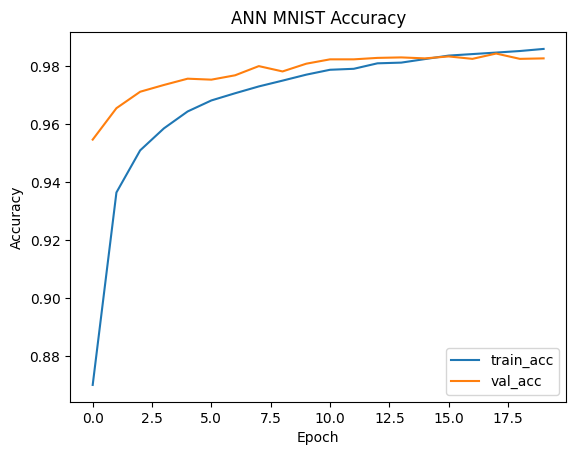

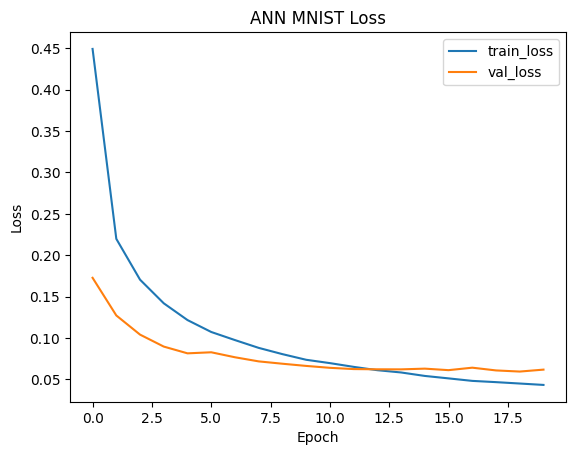

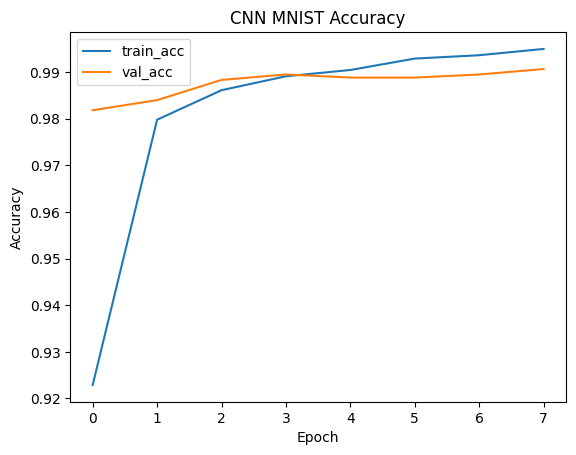

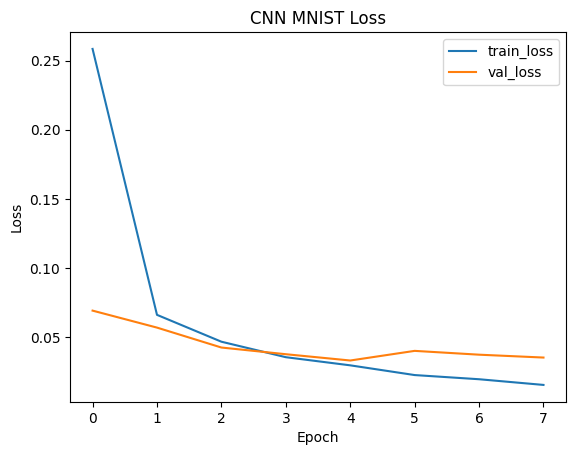

In [10]:

def plot_curves(history, title_prefix=""):
    # Accuracy
    plt.figure()
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Loss
    plt.figure()
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_curves(history_ann, "ANN MNIST")
plot_curves(history_cnn, "CNN MNIST")


## 7. Notes & Challenges (Fill Me)
- Normalization: scaled inputs to [0,1].
- Callbacks prevented overfitting by restoring best weights.
- **Your notes here:** runtime, hardware, any instability, etc.

**Quick Comparison (expected)**  
- ANN: ~97–98%  
- CNN: ~99%+  
